In [1]:
import pandas as pd
import numpy as np
df = pd.read_json("../data/price_raw.json")
df.head()

,city,property_type,surface,rooms,bedrooms,bathrooms,price,year_built
0,Lyon,NaN,28.286687,7.0,4.0,7,20279,2020
1,Lille,studio,117.438608,2.0,2.0,2,76977,2002
2,Lyon,apartment,33.276025,11.0,5.0,2,76488,2015
3,Lille,apartment,111.411069,6.0,5.0,3,15012,2000
4,Paris,studio,-199.900000,13.0,9.0,-5,41385,2023


In [2]:
print(f"dimension:{df.shape}")
print(f"types:{df.info()}")
print(f"stats:{df.describe()}")

dimension:(1017, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1017 entries, 0 to 1016
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           947 non-null    str    
 1   property_type  913 non-null    str    
 2   surface        933 non-null    float64
 3   rooms          947 non-null    float64
 4   bedrooms       922 non-null    float64
 5   bathrooms      1017 non-null   int64  
 6   price          1017 non-null   int64  
 7   year_built     1017 non-null   int64  
dtypes: float64(3), int64(3), str(2)
memory usage: 63.7 KB
types:None
stats:           surface       rooms    bedrooms    bathrooms          price  \
count   933.000000  947.000000  922.000000  1017.000000    1017.000000   
mean    130.939373    7.542767    4.716920   475.900688   61967.832842   
std     346.946841    3.428370    2.762223  2120.562807   45070.071795   
min    -199.900000    2.000000    2.000000    -5.000000      -1.000000   

In [3]:
# Valeurs manquantes
# on supprime les champs ou type et city sont vides: trop d'information manquantes
print(f"valeur manquantes par colonnes:\n{df.isna().sum(axis=0)}")
df = df.dropna(subset=["city", "property_type"], how="all")
df = df.dropna(subset=["rooms", "bedrooms"], how="all")
print(df.info())
print(df.shape)

df["city"] = df.city.apply(lambda v: "unk" if pd.isna(v) else v)
df["property_type"] = df.property_type.apply(lambda v: "unk" if pd.isna(v) else v)
df.surface = df.surface.fillna(df.surface.mean())

df.bedrooms = df.bedrooms.apply(lambda v: 1 if pd.isna(v) else v)
df.rooms = df[["rooms", "bedrooms", "bathrooms"]].apply(
    lambda row: (
        1 + row["bedrooms"] + row["bathrooms"]
        if pd.isna(row["rooms"])
        else row["rooms"]
    ),
    axis=1,
)

print(df.info())

valeur manquantes par colonnes:
city              70
property_type    104
surface           84
rooms             70
bedrooms          95
bathrooms          0
price              0
year_built         0
dtype: int64
<class 'pandas.DataFrame'>
Index: 1001 entries, 0 to 1016
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           940 non-null    str    
 1   property_type  908 non-null    str    
 2   surface        919 non-null    float64
 3   rooms          940 non-null    float64
 4   bedrooms       914 non-null    float64
 5   bathrooms      1001 non-null   int64  
 6   price          1001 non-null   int64  
 7   year_built     1001 non-null   int64  
dtypes: float64(3), int64(3), str(2)
memory usage: 70.4 KB
None
(1001, 8)
<class 'pandas.DataFrame'>
Index: 1001 entries, 0 to 1016
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   

In [4]:
# doublon
print(f"nombre de duplicate: {df.duplicated().sum()}")
df= df.drop_duplicates()
print(df[(df.city=="Lille") & np.isclose(df.surface, 132.166363)])

nombre de duplicate: 16
      city property_type     surface  rooms  bedrooms  bathrooms  price  \
38   Lille           unk  132.166363    9.0       5.0          8  64371   
86   Lille           unk  132.166363    9.0       4.0          6  29905   
241  Lille         house  132.166363    2.0       2.0          2  14580   
301  Lille     apartment  132.166363    6.0       6.0          5  34069   
670  Lille        studio  132.166363   13.0       8.0          3  44646   
823  Lille           unk  132.166363    3.0       2.0          3     -1   
955  Lille         house  132.166363   12.0       7.0       9999  17363   

     year_built  
38         1986  
86         2011  
241        2005  
301        1990  
670        1990  
823        2011  
955        2005  


surface: 91 outliers
rooms: 6 outliers
bedrooms: 10 outliers
bathrooms: 91 outliers
price: 47 outliers
year_built: 0 outliers


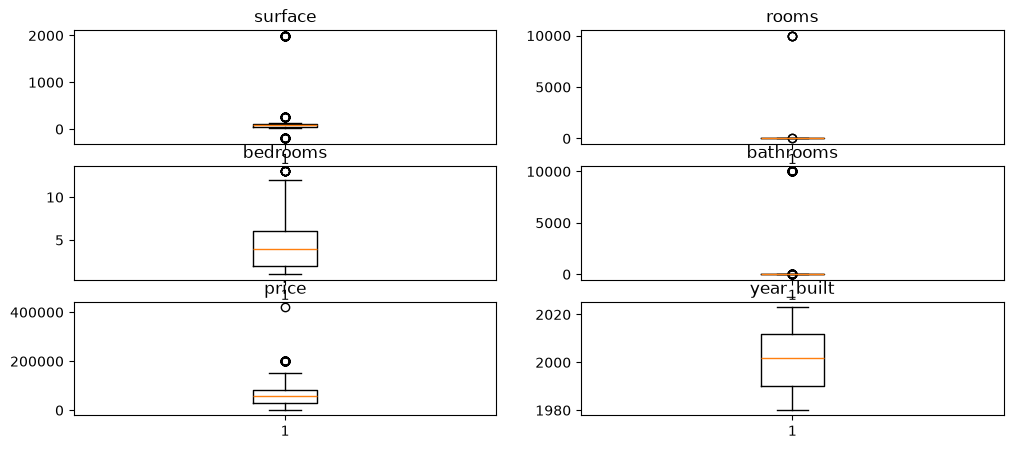

In [5]:
# Valeur abérantes
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=[np.number]).columns
def get_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

fig, axes = plt.subplots(3, 2, figsize=(12, 5))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    n_outliers = get_outliers_iqr(df, col).shape[0]
    print(f"{col}: {n_outliers} outliers")
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

In [18]:
print(df.bathrooms.value_counts().sort_index())
print(df.price.sort_values(ascending=False).head(10))

bathrooms
-5        41
 1         1
 2       243
 3       169
 4       104
 5       108
 6        89
 7        51
 8        31
 9        36
 10       35
 11       16
 12       11
 13        3
 9999     47
Name: count, dtype: int64
9       420000
1013    199999
381     199999
338     199999
946     199999
936     199999
306     199999
311     199999
919     199999
56      199999
Name: price, dtype: int64


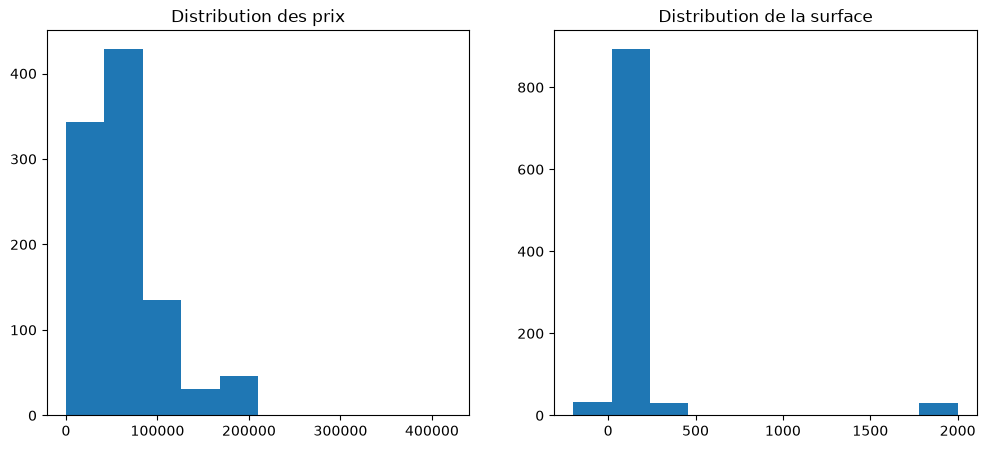

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df.price)
axes[0].set_title("Distribution des prix")

axes[1].hist(df.surface)
axes[1].set_title("Distribution de la surface")

plt.show();

In [37]:
#
print(f"prix moyen par ville:{df[["city","price"]].groupby(by= ["city"]).mean().sort_values(by="price",ascending=False)}")

df["prix_moyen_m2"] = df.price/df.surface
print(f"prix moyen au m2 par ville:{df[["prix_moyen_m2", "city"]].groupby(by="city").mean().sort_values(by="prix_moyen_m2", ascending=False)}")

prix moyen par ville:                  price
city                   
Paris      65114.781250
Marseille  65079.092784
Lyon       64989.512397
Bordeaux   64260.184932
Toulouse   64240.604167
Nantes     62979.286885
unk        57948.500000
Nice       57665.495495
Lille      55193.932692
prix moyen au m2 par ville:           prix_moyen_m2
city                    
Marseille    1034.763461
Toulouse     1007.463670
Lyon          988.947043
Bordeaux      921.825916
Lille         913.610134
unk           877.536506
Nantes        869.611925
Nice          866.840463
Paris         790.408248


property_type
unk           90
house        281
studio       285
apartment    329
Name: count, dtype: int64


<BarContainer object of 985 artists>

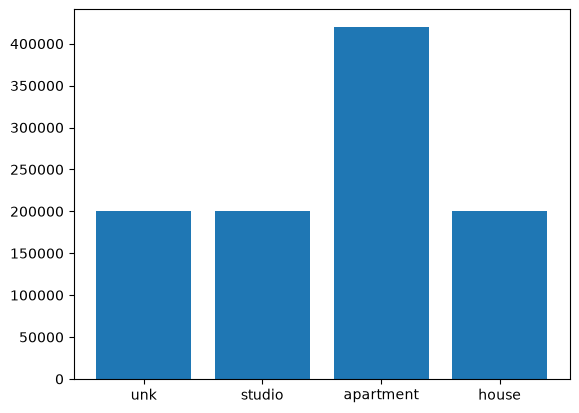

In [40]:
print(df.property_type.value_counts().sort_values())
plt.bar(df.property_type, df.price)

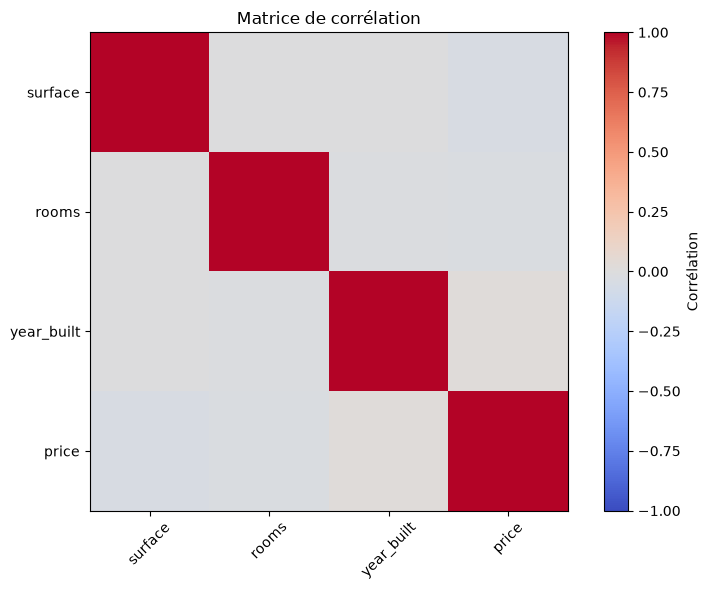

In [10]:
import matplotlib.pyplot as plt

cols_nums = ["surface", "rooms", "year_built", "price"]

corr = df[cols_nums].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Corrélation")
plt.xticks(range(len(cols_nums)), cols_nums, rotation=45)
plt.yticks(range(len(cols_nums)), cols_nums)

# Afficher les valeurs


plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

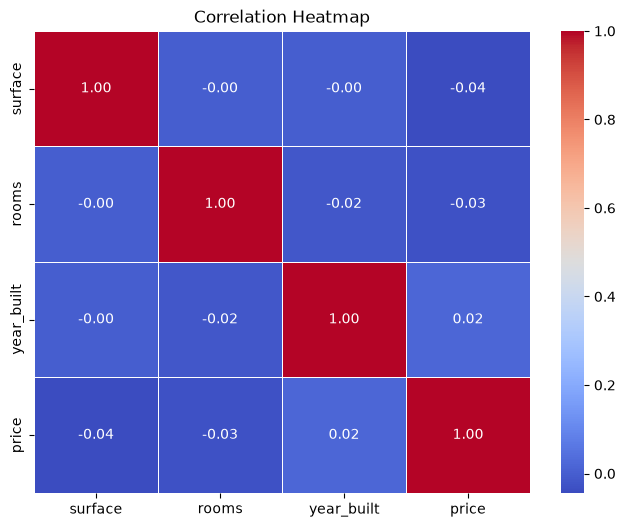

In [12]:
cols = ["surface", "rooms", "year_built", "price"]

import seaborn as sns
import matplotlib.pyplot as plt

matrix = df[cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()